In [1]:
import numpy as np
import sklearn
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import imageio.v3 as iio
import os
from PIL import Image
import imagehash
import seaborn as sns


# Data loading and Processing

In [2]:
Batch = 32
Random_seed = 42
Image_size = 96

# Modified Data Loading
full_ds = tf.keras.utils.image_dataset_from_directory(
    "Training_Bi/",
    image_size=(Image_size, Image_size),
    batch_size=None,
    shuffle=False, # Set to False to keep sequential order for sharding
    seed=Random_seed
)

# Pick 1 in every 10 frames
# num_shards=10 means split into 10 parts, index=0 takes the first part (0, 10, 20...)
full_ds = full_ds.shard(num_shards=5, index=0)

# Now calculate cardinality and shuffle the reduced dataset
total = tf.data.experimental.cardinality(full_ds).numpy()
train_size = int(0.85 * total)

# Shuffle AFTER sharding so the model sees a random mix of the 1/10th samples
full_ds = full_ds.shuffle(total, seed=Random_seed, reshuffle_each_iteration=False)

train_Bi_raw = full_ds.take(train_size)
val_Bi_raw   = full_ds.skip(train_size)

test_Bi_raw = tf.keras.utils.image_dataset_from_directory(
    "Test/",
    image_size=(Image_size, Image_size),
    batch_size=None,
    shuffle=False
)

print(f"Train: {train_size} | Val: {total - train_size} | Test: {tf.data.experimental.cardinality(test_Bi_raw).numpy()}")

Found 39375 files belonging to 2 classes.
Found 8617 files belonging to 2 classes.
Train: 6693 | Val: 1182 | Test: 8617


In [3]:
def focal_loss(gamma, alpha):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = alpha * tf.pow(1 - p_t, gamma)
        return tf.reduce_mean(focal_weight * bce)
    return loss

def augment(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    # Keep flips and rotations - they are great
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    
    # REDUCE Hue shift - fire color is a key feature!
    image = tf.image.random_hue(image, max_delta=0.02) 
    
    # DEACTIVATE Haze and Blur for now to see if recall improves
    # Or set them to a very low probability (0.1 instead of 0.5)
    return image, label
def augments(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=tf.random.uniform((), 0, 4, dtype=tf.int32))
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.7, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.6)
    image = tf.image.random_hue(image, max_delta=0.02)
    
    # Haze - fixed with tf.cond
    haze_intensity = tf.random.uniform((), 0.05, 0.25)
    haze = tf.ones_like(image) * 0.7
    image = tf.cond(
        tf.random.uniform(()) > 0.5,
        lambda: image * (1 - haze_intensity) + haze * haze_intensity,
        lambda: image
    )

    # Blur - fixed with tf.cond
    def apply_blur(img):
        img = tf.expand_dims(img, 0)
        img = tf.nn.avg_pool2d(img, ksize=3, strides=1, padding='SAME')
        return tf.squeeze(img, 0)

    image = tf.cond(
        tf.random.uniform(()) > 0.6,
        lambda: apply_blur(image),
        lambda: image
    )

    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def compute_class_weights(ds):
    labels = np.array([y.numpy() for _, y in ds])
    counts = np.bincount(labels)
    total = len(labels)
    weights = {i: total / (len(counts) * c) for i, c in enumerate(counts)}
    print(f"Class weights: {weights}")
    return weights

In [4]:
class_weights = compute_class_weights(train_Bi_raw)

train_ds = (
    train_Bi_raw
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    val_Bi_raw
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)
test_ds = (
    test_Bi_raw
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)

Class weights: {0: 0.7851947442515251, 1: 1.376593994241053}


In [ ]:
def build_model(size='medium', loss_fn=None, learning_rate=1e-3):
    if loss_fn is None:
        loss_fn = focal_loss(gamma=2.0, alpha=0.25)

    configs = {
        'tiny':   ([16], 8),
        'small':  ([16, 32], 16),
        'medium': ([16, 32, 64], 32), 
        'large':  ([32, 64, 128], 64),
    }

    filters_list, dense_units = configs[size]
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(Image_size, Image_size, 3)))

    # Use SeparableConv + BatchNormalization for efficiency
    for f in filters_list:
        model.add(keras.layers.SeparableConv2D(f, 3, padding='same'))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation('relu'))
        model.add(keras.layers.MaxPooling2D())
        model.add(keras.layers.Dropout(0.2))

    model.add(keras.layers.GlobalAveragePooling2D())
    model.add(keras.layers.Dense(dense_units, activation='relu'))
    model.add(keras.layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss=loss_fn,
        metrics=['accuracy', keras.metrics.Recall(name='recall'), keras.metrics.Precision(name='precision')]
    )
    return model

# --- COMPARISON EXECUTION LOOP ---
results = {}
models = {}  # <-- ADD THIS
model_sizes = [ 'small', 'medium','large']

for size in model_sizes:
    print(f"\n🚀 Training Model Size: {size.upper()}")
    
    m = build_model(size=size)
    
    history = m.fit(
        train_ds, 
        validation_data=val_ds, 
        epochs=15,
        class_weight=None,
        verbose=1
    )
    
    # Evaluate with return_dict=True to force individual metric keys
    eval_metrics = m.evaluate(test_ds, verbose=0, return_dict=True)  # <-- ADD return_dict=True
    
    models[size] = m  # <-- SAVE THE MODEL
    results[size] = {
        'metrics': eval_metrics,
        'history': history.history
    }


🚀 Training Model Size: TINY
Epoch 1/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.8558 - loss: 0.0276 - precision: 0.9959 - recall: 0.6055 - val_accuracy: 0.9112 - val_loss: 0.0338 - val_precision: 0.9970 - val_recall: 0.7636
Epoch 2/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9177 - loss: 0.0176 - precision: 0.9958 - recall: 0.7766 - val_accuracy: 0.9247 - val_loss: 0.0216 - val_precision: 0.9944 - val_recall: 0.8023
Epoch 3/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9187 - loss: 0.0148 - precision: 0.9932 - recall: 0.7816 - val_accuracy: 0.9112 - val_loss: 0.0152 - val_precision: 1.0000 - val_recall: 0.7614
Epoch 4/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9165 - loss: 0.0140 - precision: 0.9699 - recall: 0.7947 - val_accuracy: 0.9120 - val_loss: 0.0134 - val_precision: 0.9828 - val_recall: 0.7773
Epoch 5/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9172 - loss: 0.0135 - precision: 0.9607 - recall: 0.8050 - 

In [6]:
import pandas as pd

# Debug: see what's actually inside compile_metrics
for size, data in results.items():
    print(f"{size} eval_metrics: {data['metrics']}")

summary_data = []

for size, data in results.items():
    # Re-evaluate to get individual metrics
    eval_result = models[size].evaluate(test_ds, verbose=0, return_dict=True)
    print(f"{size} full eval: {eval_result}")
    
    row = {
        'Size':      size,
        'Accuracy':  eval_result.get('accuracy'),
        'Recall':    eval_result.get('recall'),
        'Precision': eval_result.get('precision'),
        'Loss':      eval_result.get('loss'),
    }
    summary_data.append(row)
df = pd.DataFrame(summary_data)

# Sort BEFORE formatting (while values are still numeric)
df = df.sort_values(by='Recall', ascending=False)

# Format after sorting
cols_to_fix = ['Accuracy', 'Recall', 'Precision']
for col in cols_to_fix:
    df[col] = df[col].apply(lambda x: f"{x*100:.2f}%" if x is not None else "N/A")

print("\n--- MODEL COMPARISON SUMMARY ---")
print(df.to_string(index=False))

tiny eval_metrics: {'accuracy': 0.578971803188324, 'loss': 0.06584551930427551, 'precision': 0.4807090759277344, 'recall': 0.5298850536346436}
small eval_metrics: {'accuracy': 0.5569223761558533, 'loss': 0.10924328118562698, 'precision': 0.429170161485672, 'recall': 0.294252872467041}
medium eval_metrics: {'accuracy': 0.6586979031562805, 'loss': 0.07978057116270065, 'precision': 0.5796630382537842, 'recall': 0.5635057687759399}
tiny full eval: {'accuracy': 0.578971803188324, 'loss': 0.06584551930427551, 'precision': 0.4807090759277344, 'recall': 0.5298850536346436}
small full eval: {'accuracy': 0.5569223761558533, 'loss': 0.10924328118562698, 'precision': 0.429170161485672, 'recall': 0.294252872467041}
medium full eval: {'accuracy': 0.6586979031562805, 'loss': 0.07978057116270065, 'precision': 0.5796630382537842, 'recall': 0.5635057687759399}

--- MODEL COMPARISON SUMMARY ---
  Size Accuracy Recall Precision     Loss
medium   65.87% 56.35%    57.97% 0.079781
  tiny   57.90% 52.99%    4

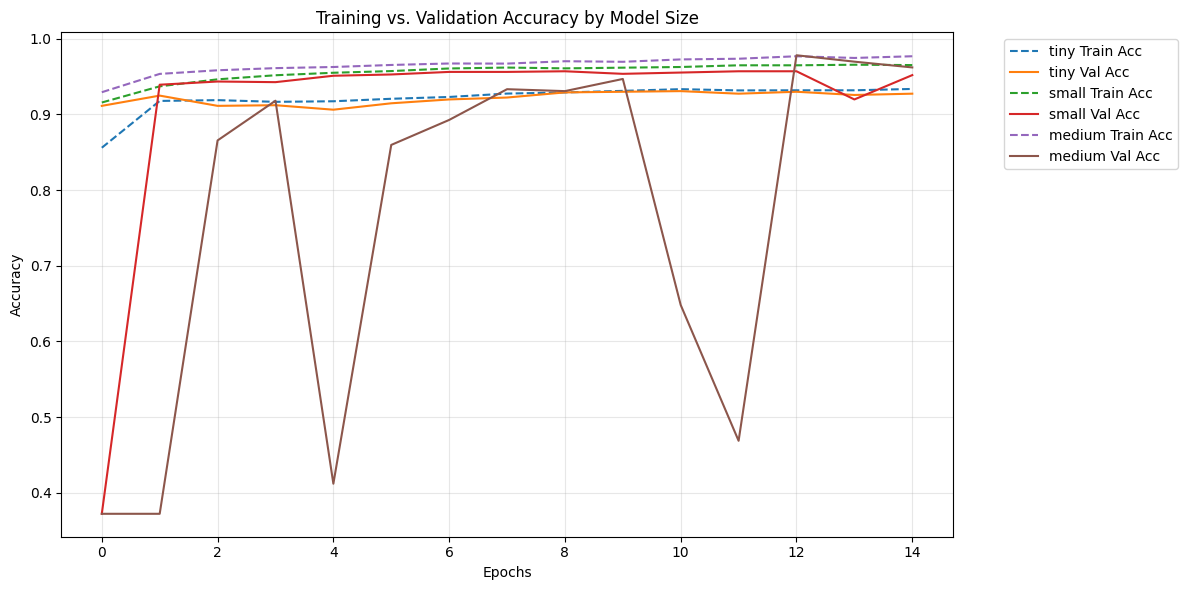

In [7]:
plt.figure(figsize=(12, 6))

for size in results:
    # Training Accuracy (Solid line)
    plt.plot(results[size]['history']['accuracy'], 
             label=f'{size} Train Acc', linestyle='--')
    
    # Validation Accuracy (Dashed line)
    plt.plot(results[size]['history']['val_accuracy'], 
             label=f'{size} Val Acc')

plt.title('Training vs. Validation Accuracy by Model Size')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

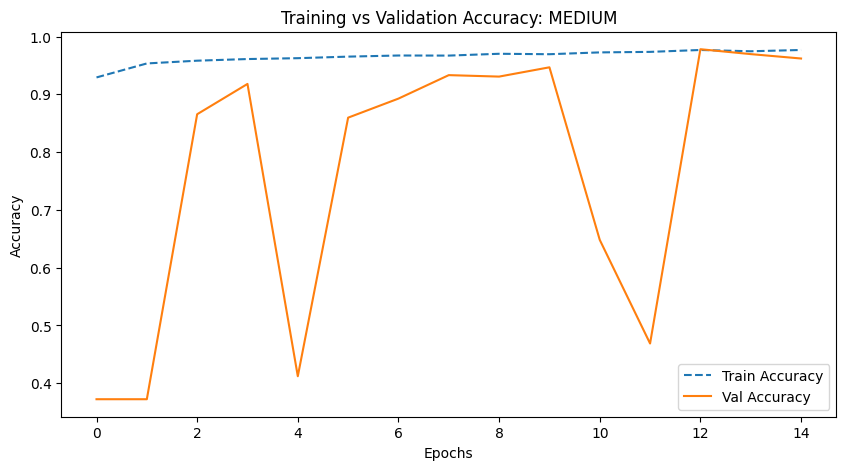

In [8]:
size = 'medium'
hist = results[size]['history']

plt.figure(figsize=(10, 5))
plt.plot(hist['accuracy'], label='Train Accuracy', linestyle='--')
plt.plot(hist['val_accuracy'], label='Val Accuracy')

plt.title(f'Training vs Validation Accuracy: {size.upper()}')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

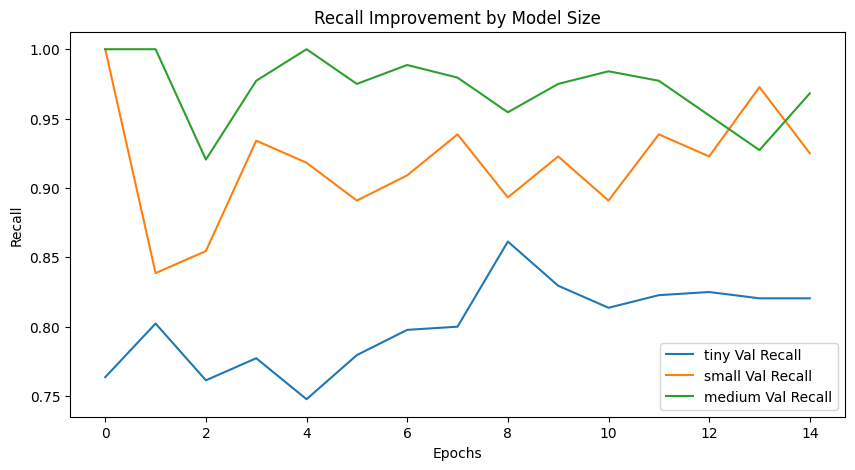

In [9]:
plt.figure(figsize=(10, 5))
for size in results:
    plt.plot(results[size]['history']['val_recall'], label=f'{size} Val Recall')

plt.title('Recall Improvement by Model Size')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.show()